In [1]:
import altair as alt
import json
import pandas as pd
import operator
import os
import re
import statsmodels.api as sm
import matplotlib.pyplot as plt

from statistics import mean

In [2]:
visus_folder_name = 'visualizations'
os.makedirs(visus_folder_name, exist_ok=True)
visus_path = os.path.join(os.getcwd(), visus_folder_name)

In [3]:
df = pd.read_json('./evaluation/few-shot/aggregate_metrics.json')
df

,sabia-3.1,granite-3-3-8b-instruct,gemini-2.5-flash,gpt-4,llama-3-405b-instruct
punchlines,"{'dice_similarity': 0.5864655386237151, 'leven...","{'dice_similarity': 0.027473348161923, 'levens...","{'dice_similarity': 0.7142824077855591, 'leven...","{'dice_similarity': 0.726885298356532, 'levens...","{'dice_similarity': 0.646843156162171, 'levens..."
comic_styles,"{'f1_score': {'fun': 0.7482014388489201, 'humo...","{'f1_score': {'fun': 0.8158567774936061, 'humo...","{'f1_score': {}, 'precision': {}, 'recall': {}...","{'f1_score': {'fun': 0.8602941176470581, 'humo...","{'f1_score': {'fun': 0.8490284005979071, 'humo..."
texts_explanations,4.090526,3.543158,NaN,NaN,NaN


In [4]:
apelidos = {
    'gemma-3-gaia-pt-br-4b-it': 'Gemma 3 Gaia (4B)',
    'mixtral-8x7b-instruct-v01': 'Mixtral v01 (8×7B)',
    'sabia-3.1': 'Sabia 3.1',
    'granite-3-3-8b-instruct': 'Granite 3.3 (8B)',
    'gemini-2.5-flash': 'Gemini 2.5 Flash',
    'gpt-4': 'GPT-4',
    'llama-3-405b-instruct': 'LLaMA 3 (405B)',
    'deepseek-r1-0528-qwen3-8b': 'DeepSeek R1 (8B)',
    'gervasio-7b-portuguese-ptbr-decoder': 'Gervasio (7B)'
}

df = df.rename(columns=apelidos)

In [5]:
df_punchlines = pd.DataFrame(df.loc["punchlines"].tolist(), index=df.columns)
df_punchlines

,dice_similarity,levenshtein_distance,hit_rate_pre_treatment,hit_rate
Sabia 3.1,0.586466,23.290526,0.949474,0.953684
Granite 3.3 (8B),0.027473,34.111579,0.006316,0.050526
Gemini 2.5 Flash,0.714282,18.738397,0.991561,0.995781
GPT-4,0.726885,21.724211,0.997895,0.997895
LLaMA 3 (405B),0.646843,21.197895,0.981053,0.989474


In [6]:
df_dice = df_punchlines[['dice_similarity']].reset_index().rename(columns={'index': 'model'})
df_lev = df_punchlines[['levenshtein_distance']].reset_index().rename(columns={'index': 'model'})

dice_order = df_dice.sort_values('dice_similarity')['model'].tolist()[::-1]
lev_order = df_lev.sort_values('levenshtein_distance')['model'].tolist()[::1]

chart_dice = alt.layer(
    alt.Chart(df_dice).mark_bar(size=80).encode(
        x=alt.X('model:N', sort=dice_order, title=' ',
                scale=alt.Scale(paddingInner=0.1), axis=alt.Axis(grid=False)),
        y=alt.Y('dice_similarity:Q', title='Média da Similaridade de Dice', axis=alt.Axis(grid=False)),
        color=alt.Color('model:N', legend=None)
    ),
    alt.Chart(df_dice).mark_text(
        align='center',
        baseline='bottom',
        dy=-2
    ).encode(
        x=alt.X('model:N', sort=dice_order),
        y='dice_similarity:Q',
        text=alt.Text('dice_similarity:Q', format=".2f")
    )
).properties(
    width=850,
    height=300,
    title='Sobreposição de Punchlines por Modelo (Similaridade de Dice)'
).configure_axisX(
    labelAngle=0,
    labelAlign='center'
)

chart_dice.save(os.path.join(visus_path, "similaridade_dice.png"), scale_factor=3.0)
chart_dice.show()

alt.LayerChart(...)

In [7]:
df_texts_explanations = df.loc["texts_explanations"].to_frame().T
df_texts_explanations

,Sabia 3.1,Granite 3.3 (8B),Gemini 2.5 Flash,GPT-4,LLaMA 3 (405B)
texts_explanations,4.090526,3.543158,NaN,NaN,NaN


In [8]:
texts_expl = df.loc["texts_explanations"].astype(float)
texts_df = texts_expl.reset_index()
texts_df.columns = ["Modelo", "Concordância Média"]

max_val = texts_df["Concordância Média"].max()

chart = alt.layer(
    alt.Chart(texts_df).mark_bar(size=80).encode(
        y=alt.Y('Concordância Média:Q',
                title='Nível médio de concordância (Modelo Juiz)',
                scale=alt.Scale(domain=[1, max_val * 1.05], clamp=True),  # começa em 1 e folga no topo
                axis=alt.Axis(grid=False)),
        x=alt.X('Modelo:N',
                sort='-y',
                title='',
                axis=alt.Axis(grid=False, labelAngle=0)),
        color=alt.Color('Modelo:N', legend=None),
        tooltip=["Modelo", "Concordância Média"]
    ),
    alt.Chart(texts_df).mark_text(
        align='center',
        baseline='bottom',
        dy=-3
    ).encode(
        x=alt.X('Modelo:N', sort='-y'),
        y='Concordância Média:Q',
        text=alt.Text('Concordância Média:Q', format='.2f')
    )
).properties(
    width=850,
    height=400,
    title="Avaliação das Explicações dos Textos Humorísticos por Modelo"
)

chart.save(os.path.join(visus_path, "explicacoes_concordancia.png"), scale_factor=3.0)
chart

alt.LayerChart(...)

In [9]:
df_comic_styles = pd.DataFrame(df.loc["comic_styles"].dropna().tolist(), index=df.columns[df.loc["comic_styles"].notna()])
df_comic_styles

,f1_score,precision,recall,accuracy,f1_macro,f1_micro,hit_rate_pre_treatment,hit_rate,omission_rate
Sabia 3.1,"{'fun': 0.7482014388489201, 'humor': 0.6390728...","{'fun': 0.7854984894259811, 'humor': 0.7628458...","{'fun': 0.7142857142857141, 'humor': 0.5498575...","{'fun': 0.631578947368421, 'humor': 0.54105263...",0.247876,0.991507,0.0,1.000000,0.000000
Granite 3.3 (8B),"{'fun': 0.8158567774936061, 'humor': 0.8134715...","{'fun': 0.763157894736842, 'humor': 0.74584323...","{'fun': 0.876373626373626, 'humor': 0.89458689...","{'fun': 0.696842105263157, 'humor': 0.69684210...",0.213995,0.874259,0.0,1.000000,0.000000
Gemini 2.5 Flash,{},{},{},{},NaN,NaN,0.0,0.000000,0.000000
GPT-4,"{'fun': 0.8602941176470581, 'humor': 0.8073136...","{'fun': 0.7765486725663711, 'humor': 0.7972222...","{'fun': 0.9642857142857141, 'humor': 0.8176638...","{'fun': 0.76, 'humor': 0.7115789473684211, 'no...",0.239618,0.960044,1.0,1.000000,0.000000
LLaMA 3 (405B),"{'fun': 0.8490284005979071, 'humor': 0.8680089...","{'fun': 0.7634408602150531, 'humor': 0.8255319...","{'fun': 0.9562289562289561, 'humor': 0.9150943...","{'fun': 0.7410256410256411, 'humor': 0.7862318...",0.223640,0.901961,0.0,0.768684,0.231316


In [10]:
def graph_all_models_per_style(model_names):
    data = []

    for model_name in model_names:
        f1_scores = df_comic_styles.loc[model_name]['f1_score']
        for style, score in f1_scores.items():
            data.append({
                'style': style,
                'model': model_name,
                'score': score
            })

    df_all = pd.DataFrame(data)

    chart = alt.Chart(df_all).mark_bar().encode(
        x=alt.X('style:N', title=None, axis=alt.Axis(labelAngle=0)),
        y=alt.Y('score:Q', title='F1-Score'),
        color=alt.Color('model:N', title='Modelo'),
        xOffset=alt.X('model:N')  # <-- barras lado a lado dentro do mesmo estilo
    ).properties(
        width=500,
        height=400,
        title='F1-Score por Estilo Cômico e Modelo'
    )

    chart.save(os.path.join(visus_path, "f1_per_style_all_models.png"), scale_factor=3.0)
    chart.show()

model_names = df_comic_styles.index
graph_all_models_per_style(model_names)

alt.Chart(...)

### Análise qualitativa 1 - Erros e acertos em comum 

In [11]:
MIN_MODELS_REPEATS = 5

WORSE_PUNCHLINES_THRESHOLD = 0.4
BETTER_PUNCHLINES_THRESHOLD = 0.6

WORSE_EXPLANATIONS_THRESHOLD = 2
BETTER_EXPLANATIONS_THRESHOLD = 4

In [12]:
original_df = pd.read_csv('./data/brazilian_ne_annotated_humorous_texts.csv')
def clean_text(x):
    if pd.isna(x):
        return x
    return re.sub(r"\s+", " ", str(x)).strip()

comic_columns = ['fun', 'humor', 'nonsense', 'wit', 'irony', 'satire', 'sarcasm', 'cynicism']
original_df["video_url"] = original_df["video_url"].apply(clean_text).str.lower()
original_df["corrected_transcription"] = original_df["corrected_transcription"].apply(clean_text)
original_df['comic_styles'] = original_df[comic_columns].apply(lambda row: [col for col in comic_columns if row[col] == 1], axis=1)
original_df['text_len'] = original_df['corrected_transcription'].apply(lambda text: len(text))
original_df['text_words_count'] = original_df['corrected_transcription'].apply(lambda text: len(text.split()))

In [13]:
ft_df = original_df[['video_url', 'corrected_transcription', 'punchlines', 'joke_explanation'] + comic_columns]
ft_df.head(2)

,video_url,corrected_transcription,punchlines,joke_explanation,fun,humor,nonsense,wit,irony,satire,sarcasm,cynicism
0,https://www.youtube.com/shorts/xcve3ifsxwg?fea...,"Humorista: O cara me chamou falou aqui ó, puxo...","Eu falei, vai buscar mais. Isso aí não dá nem ...","O humorista narra uma cena tensa, porém cômica...",1,1,0,0,1,0,1,0
1,https://www.youtube.com/shorts/qv80ekixlyc?fea...,Humorista: Quem já passou algumas coisas muito...,E ele tem a cara de pau de dizer era Cerveja!;...,O humorista desdenha da marca Crystal a partir...,1,1,0,1,0,1,1,0


#### 1.0 Estilos cômicos

In [14]:
json_path = './evaluation/few-shot/individual_metrics.json'
with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

rows = []
for model_key, content in data.items():
    for style_metric in content.get("comic_styles", []): 
        row = {"source_model_key": model_key}
        row.update(style_metric)
        rows.append(row)

comic_styles_df = pd.DataFrame(rows)
required_cols = {"model_name", "is_correct", "comic_style", "humorous_text"}
missing = required_cols - set(comic_styles_df.columns)
if missing:
    raise ValueError(f"Missing expected columns in data: {missing}")

comic_styles_df["humorous_text"] = comic_styles_df["humorous_text"].astype(str).str.strip()

def get_common_texts_by_style(df, correct_flag, min_models=5):
    filtered = df[df["is_correct"] == correct_flag].copy()
    grouped_results = []

    for style, style_df in filtered.groupby("comic_style"):
        counts_per_model = (
            style_df.groupby(["humorous_text", "model_name"])
            .size()
            .unstack(fill_value=0)
        )
        counts_per_model["num_models"] = (counts_per_model > 0).sum(axis=1)
        mask = counts_per_model["num_models"] >= min_models
        common_texts = counts_per_model[mask].sort_values("num_models", ascending=False)

        if not common_texts.empty:
            temp_df = common_texts.reset_index()
            temp_df["comic_style"] = style
            model_cols = [c for c in temp_df.columns if c not in {"humorous_text", "comic_style", "num_models"}]
            temp_df["models"] = temp_df[model_cols].apply(
                lambda row: [m for m in model_cols if row[m] > 0],
                axis=1
            )
            grouped_results.append(temp_df[["comic_style", "humorous_text", "num_models", "models"]])

    if grouped_results:
        return pd.concat(grouped_results, ignore_index=True)
    else:
        return pd.DataFrame(columns=["comic_style", "humorous_text", "num_models", "models"])

comic_styles_common_errors_df = get_common_texts_by_style(comic_styles_df, correct_flag=0, min_models=MIN_MODELS_REPEATS)
comic_styles_common_correct_df = get_common_texts_by_style(comic_styles_df, correct_flag=1, min_models=MIN_MODELS_REPEATS)

#### 1.1 Punchlines

In [15]:
rows = []
for model_key, content in data.items():
    for punchline in content.get("punchlines", []):
        row = {"source_model_key": model_key}
        row.update(punchline)
        rows.append(row)

punchlines_results_df = pd.DataFrame(rows)
required_cols = {"video_url", "dice_similarity", "humorous_text", "model_name"}
missing = required_cols - set(punchlines_results_df.columns)
if missing:
    raise ValueError(f"Missing expected columns in data: {missing}")

punchlines_results_df["video_url"] = punchlines_results_df["video_url"].apply(clean_text).str.lower()
punchlines_results_df["humorous_text"] = punchlines_results_df["humorous_text"].apply(clean_text)
punchlines_metrics_results = (
    punchlines_results_df.groupby(["video_url", "humorous_text"])
      .apply(lambda g: dict(zip(g["model_name"], g["dice_similarity"])))
      .reset_index(name="models_dice_similarity_scores")
)

punchlines_metrics_results.head(2)

/tmp/ipykernel_580839/4164717186.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: dict(zip(g["model_name"], g["dice_similarity"])))


,video_url,humorous_text,models_dice_similarity_scores
0,https://www.youtube.com/shorts/-854rwb9xnm?fea...,"Humorista: Vocês conhecem algum homem trans, m...","{'sabia-3.1': 0.8, 'granite-3-3-8b-instruct': ..."
1,https://www.youtube.com/shorts/-i0boo7f-bi?fea...,Geraldo: Ô rapidinho! Personagem 1: Eu tô te d...,"{'sabia-3.1': 0.4666666666666667, 'granite-3-3..."


In [16]:
punchlines_merged_df = original_df.merge(punchlines_metrics_results, on = 'video_url', how = 'left')
punchlines_merged_df['models_dice_similarity_scores_mean'] = punchlines_merged_df['models_dice_similarity_scores'].apply(lambda metrics: mean(metrics.values()))
punchlines_merged_df.head(2)

,video_url,video_title,publish_date,brazilian_state,text_origin,corrected_transcription,specific_contexts,punchlines,fun,humor,...,satire,sarcasm,cynicism,joke_explanation,comic_styles,text_len,text_words_count,humorous_text,models_dice_similarity_scores,models_dice_similarity_scores_mean
0,https://www.youtube.com/shorts/xcve3ifsxwg?fea...,O CARA PUXOU A PISTOLA PRA MIM E EU... - EMERS...,"Dec 6, 2022",Ceará,Podcast,"Humorista: O cara me chamou falou aqui ó, puxo...","""Ovo virado"" é uma gíria pra indicar que algué...","Eu falei, vai buscar mais. Isso aí não dá nem ...",1,1,...,0,1,0,"O humorista narra uma cena tensa, porém cômica...","[fun, humor, irony, sarcasm]",702,130,"Humorista: O cara me chamou falou aqui ó, puxo...","{'sabia-3.1': 0.4, 'granite-3-3-8b-instruct': ...",0.555272
1,https://www.youtube.com/shorts/qv80ekixlyc?fea...,Cachaçaaa😂😂 - Flavio Andradde - #shorts,"Oct 30, 2024",Pernambuco,Stand-up,Humorista: Quem já passou algumas coisas muito...,Record é uma rede de televisão comercial abert...,E ele tem a cara de pau de dizer era Cerveja!;...,1,1,...,1,1,0,O humorista desdenha da marca Crystal a partir...,"[fun, humor, wit, satire, sarcasm]",765,131,Humorista: Quem já passou algumas coisas muito...,"{'sabia-3.1': 0.9122807017543859, 'granite-3-3...",0.592552


In [17]:
X = punchlines_merged_df[comic_columns]
y = punchlines_merged_df['models_dice_similarity_scores_mean']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                                    OLS Regression Results                                    
Dep. Variable:     models_dice_similarity_scores_mean   R-squared:                       0.041
Model:                                            OLS   Adj. R-squared:                  0.024
Method:                                 Least Squares   F-statistic:                     2.472
Date:                                Wed, 03 Sep 2025   Prob (F-statistic):             0.0124
Time:                                        08:21:09   Log-Likelihood:                 260.07
No. Observations:                                 475   AIC:                            -502.1
Df Residuals:                                     466   BIC:                            -464.7
Df Model:                                           8                                         
Covariance Type:                            nonrobust                                         
                 coef    std err          t      P

In [18]:
models = list(punchlines_merged_df['models_dice_similarity_scores'][0].keys())
for model_name in models:
    X = punchlines_merged_df[comic_columns]
    X = sm.add_constant(X)
    y = [scores[model_name] for scores in punchlines_merged_df['models_dice_similarity_scores']]

    model = sm.OLS(y, X).fit()
    print(f'--- {model_name} ---')
    print(model.summary())

--- sabia-3.1 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.378
Date:                Wed, 03 Sep 2025   Prob (F-statistic):              0.203
Time:                        08:21:09   Log-Likelihood:                -27.020
No. Observations:                 475   AIC:                             72.04
Df Residuals:                     466   BIC:                             109.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5625      0.045  

KeyError: 'gemini-2.5-flash'

In [ ]:
def get_common_texts(df, metric_column, threshold, comparison_op, min_repeats=4):
    df_filtered = df[comparison_op(df[metric_column], threshold)].copy()
    df_filtered["humorous_text"] = df_filtered["humorous_text"].astype(str).str.strip()
    text_to_url = df_filtered.groupby("humorous_text")["video_url"].first().reset_index()

    counts_per_model = (
        df_filtered
        .groupby(["humorous_text", "model_name"])
        .size()
        .unstack(fill_value=0)
    )
    counts_per_model["total_occurrences"] = counts_per_model.sum(axis=1)

    repeated_mask = counts_per_model["total_occurrences"] >= min_repeats
    repeated_texts_counts = counts_per_model[repeated_mask].sort_values("total_occurrences", ascending=False)
    repeated_texts_df = repeated_texts_counts[["total_occurrences"]].reset_index()

    model_cols = [c for c in counts_per_model.columns if c != "total_occurrences"]
    repeated_texts_df["models"] = repeated_texts_counts[model_cols].apply(
        lambda row: [m for m in model_cols if row[m] > 0],
        axis=1
    ).values

    metrics_dict = (
        df_filtered.groupby(["humorous_text", "model_name"])[metric_column]
        .mean()
        .unstack(fill_value=None)
    )
    repeated_texts_df[f"model_{metric_column}_scores"] = repeated_texts_df["humorous_text"].map(
        lambda txt: metrics_dict.loc[txt].dropna().to_dict()
    )

    repeated_texts_df = repeated_texts_df.merge(text_to_url, on="humorous_text", how="left")
    repeated_texts_df = repeated_texts_df.merge(
        original_df.groupby("video_url").agg({
            "joke_explanation": "first",
            "punchlines": "first",
            "comic_styles": "first"
        }).reset_index(),
        on="video_url",
        how="left"
    )

    return repeated_texts_df.reset_index(drop=True)

punchlines_worse_results_df = get_common_texts(punchlines_results_df, 'dice_similarity', WORSE_PUNCHLINES_THRESHOLD, operator.le, min_repeats=MIN_MODELS_REPEATS)
punchlines_better_results_df = get_common_texts(punchlines_results_df, 'dice_similarity', BETTER_PUNCHLINES_THRESHOLD, operator.ge, min_repeats=MIN_MODELS_REPEATS)

#### 1.2 Explicações dos textos humorísticos

In [ ]:
rows = []
for model_key, content in data.items():
    for punchline in content.get("texts_explanations", []):
        row = {"source_model_key": model_key}
        row.update(punchline)
        rows.append(row)

explanations_results_df = pd.DataFrame(rows)
explanations_results_df['agreement_level'] = explanations_results_df['judge_model_results'].apply(lambda results: int(results['nivel_concordancia']))

required_cols = {"agreement_level", "humorous_text", "model_name"}
missing = required_cols - set(explanations_results_df.columns)
if missing:
    raise ValueError(f"Missing expected columns in data: {missing}")

explanations_worse_results_df = get_common_texts(explanations_results_df, 'agreement_level', WORSE_EXPLANATIONS_THRESHOLD, operator.le, min_repeats=MIN_MODELS_REPEATS)
explanations_better_results_df = get_common_texts(explanations_results_df, 'agreement_level', BETTER_EXPLANATIONS_THRESHOLD, operator.ge, min_repeats=MIN_MODELS_REPEATS)

In [ ]:
explanations_results_df["video_url"] = explanations_results_df["video_url"].apply(clean_text).str.lower()
explanations_results_df["humorous_text"] = explanations_results_df["humorous_text"].apply(clean_text)
explanations_metrics_results = (
    explanations_results_df.groupby(["video_url", "humorous_text"])
      .apply(lambda g: dict(zip(g["model_name"], g["agreement_level"])))
      .reset_index(name="models_agreement_level_scores")
)

explanations_metrics_results.head(2)

/tmp/ipykernel_5301/2662053372.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: dict(zip(g["model_name"], g["agreement_level"])))


,video_url,humorous_text,models_agreement_level_scores
0,https://www.youtube.com/shorts/-854rwb9xnm?fea...,"Humorista: Vocês conhecem algum homem trans, m...","{'gemma-3-gaia-pt-br-4b-it': 2, 'mixtral-8x7b-..."
1,https://www.youtube.com/shorts/-i0boo7f-bi?fea...,Geraldo: Ô rapidinho! Personagem 1: Eu tô te d...,"{'gemma-3-gaia-pt-br-4b-it': 5, 'mixtral-8x7b-..."


In [ ]:
explanations_merged_df = original_df.merge(explanations_metrics_results, on = 'video_url', how = 'left')
explanations_merged_df['models_agreement_level_scores_mean'] = explanations_metrics_results['models_agreement_level_scores'].apply(lambda metrics: mean(metrics.values()))
explanations_merged_df.head(2)

,video_url,video_title,publish_date,brazilian_state,text_origin,corrected_transcription,specific_contexts,punchlines,fun,humor,...,satire,sarcasm,cynicism,joke_explanation,comic_styles,text_len,text_words_count,humorous_text,models_agreement_level_scores,models_agreement_level_scores_mean
0,https://www.youtube.com/shorts/xcve3ifsxwg?fea...,O CARA PUXOU A PISTOLA PRA MIM E EU... - EMERS...,"Dec 6, 2022",Ceará,Podcast,"Humorista: O cara me chamou falou aqui ó, puxo...","""Ovo virado"" é uma gíria pra indicar que algué...","Eu falei, vai buscar mais. Isso aí não dá nem ...",1,1,...,0,1,0,"O humorista narra uma cena tensa, porém cômica...","[fun, humor, irony, sarcasm]",702,130,"Humorista: O cara me chamou falou aqui ó, puxo...","{'gemma-3-gaia-pt-br-4b-it': 1, 'mixtral-8x7b-...",3.250
1,https://www.youtube.com/shorts/qv80ekixlyc?fea...,Cachaçaaa😂😂 - Flavio Andradde - #shorts,"Oct 30, 2024",Pernambuco,Stand-up,Humorista: Quem já passou algumas coisas muito...,Record é uma rede de televisão comercial abert...,E ele tem a cara de pau de dizer era Cerveja!;...,1,1,...,1,1,0,O humorista desdenha da marca Crystal a partir...,"[fun, humor, wit, satire, sarcasm]",765,131,Humorista: Quem já passou algumas coisas muito...,"{'gemma-3-gaia-pt-br-4b-it': 1, 'mixtral-8x7b-...",4.875


In [ ]:
X = explanations_merged_df[comic_columns]
y = explanations_merged_df['models_agreement_level_scores_mean']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                                    OLS Regression Results                                    
Dep. Variable:     models_agreement_level_scores_mean   R-squared:                       0.012
Model:                                            OLS   Adj. R-squared:                 -0.005
Method:                                 Least Squares   F-statistic:                    0.7092
Date:                                Tue, 19 Aug 2025   Prob (F-statistic):              0.684
Time:                                        14:59:23   Log-Likelihood:                -557.43
No. Observations:                                 475   AIC:                             1133.
Df Residuals:                                     466   BIC:                             1170.
Df Model:                                           8                                         
Covariance Type:                            nonrobust                                         
                 coef    std err          t      P

--- gemma-3-gaia-pt-br-4b-it ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.604
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.121
Time:                        14:59:40   Log-Likelihood:                -822.25
No. Observations:                 475   AIC:                             1663.
Df Residuals:                     466   BIC:                             1700.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.02

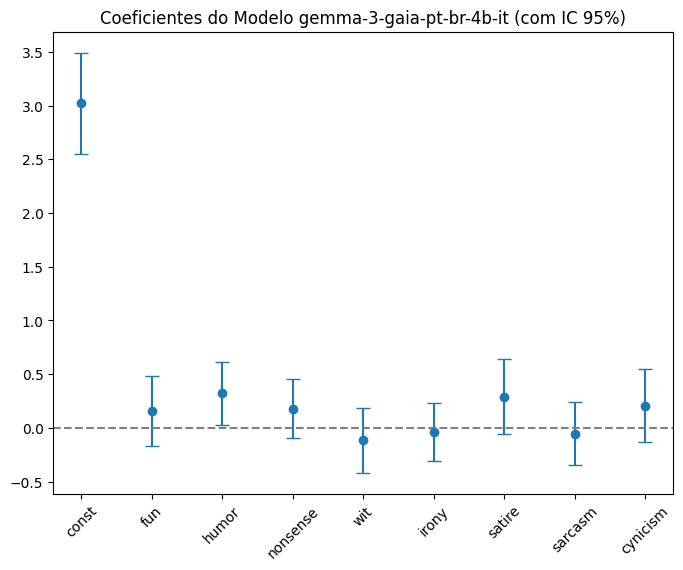

--- mixtral-8x7b-instruct-v01 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.107
Date:                Tue, 19 Aug 2025   Prob (F-statistic):             0.0338
Time:                        14:59:40   Log-Likelihood:                -802.08
No. Observations:                 475   AIC:                             1622.
Df Residuals:                     466   BIC:                             1660.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5

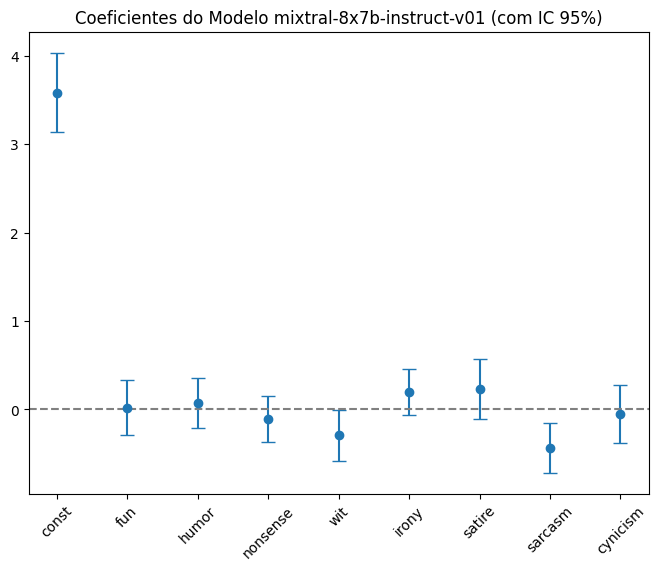

--- sabia-3.1 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.144
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.332
Time:                        14:59:40   Log-Likelihood:                -756.26
No. Observations:                 475   AIC:                             1531.
Df Residuals:                     466   BIC:                             1568.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1832      0.208  

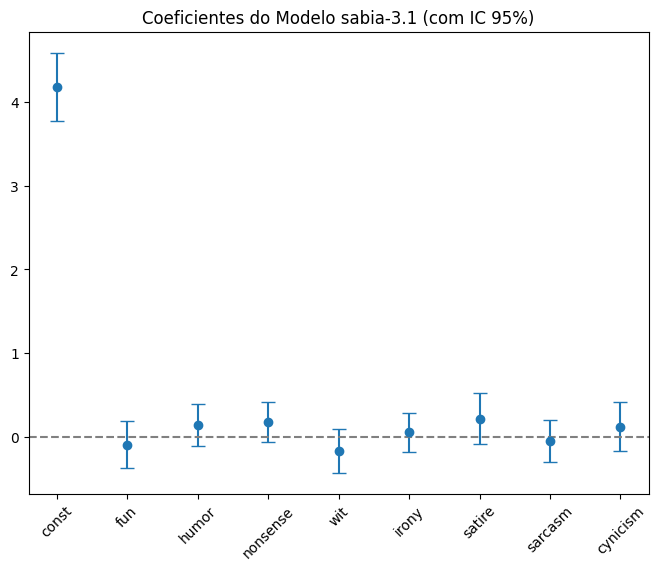

--- granite-3-3-8b-instruct ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.008
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.429
Time:                        14:59:40   Log-Likelihood:                -822.53
No. Observations:                 475   AIC:                             1663.
Df Residuals:                     466   BIC:                             1701.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.887

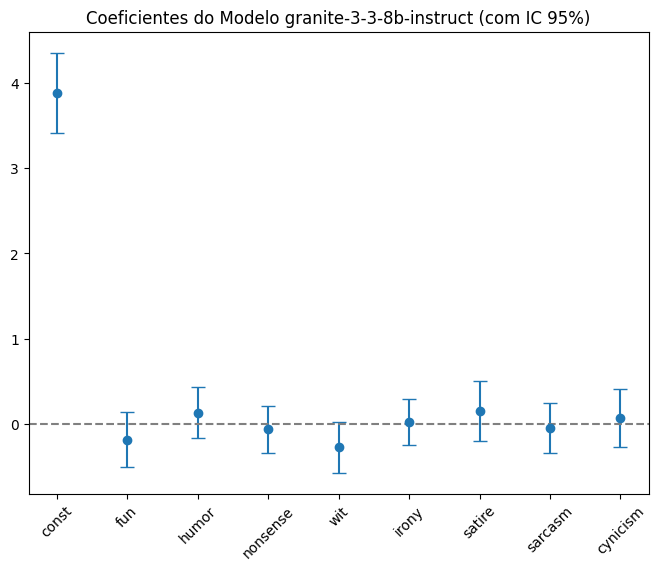

--- gemini-2.5-flash ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.6419
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.743
Time:                        14:59:40   Log-Likelihood:                -593.37
No. Observations:                 475   AIC:                             1205.
Df Residuals:                     466   BIC:                             1242.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8031      

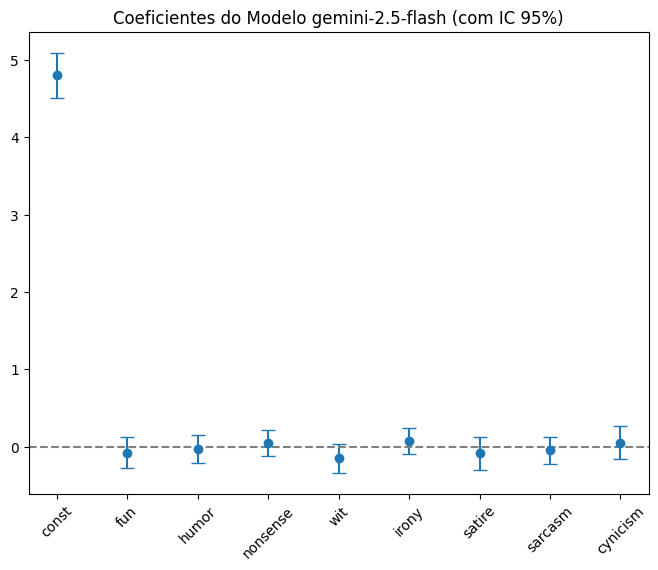

--- gpt-4 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.3529
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.944
Time:                        14:59:40   Log-Likelihood:                -735.91
No. Observations:                 475   AIC:                             1490.
Df Residuals:                     466   BIC:                             1527.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4488      0.199     2

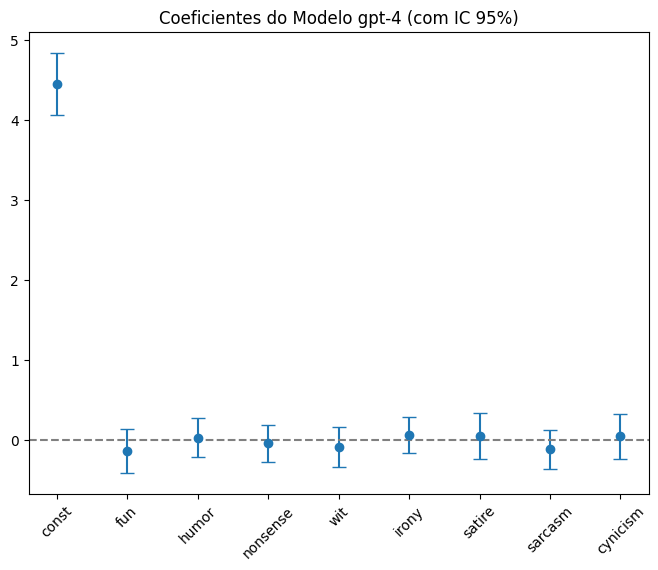

--- llama-3-405b-instruct ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9142
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.504
Time:                        14:59:40   Log-Likelihood:                -766.64
No. Observations:                 475   AIC:                             1551.
Df Residuals:                     466   BIC:                             1589.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0151 

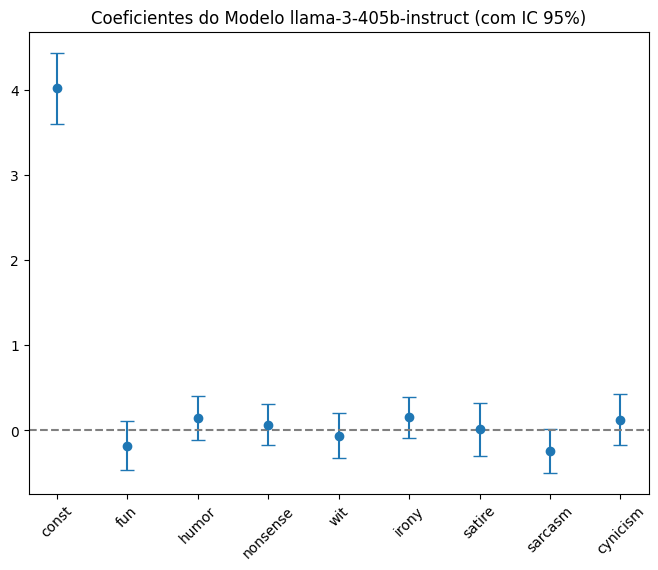

--- deepseek-r1-0528-qwen3-8b ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.4507
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.890
Time:                        14:59:41   Log-Likelihood:                -825.62
No. Observations:                 475   AIC:                             1669.
Df Residuals:                     466   BIC:                             1707.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8

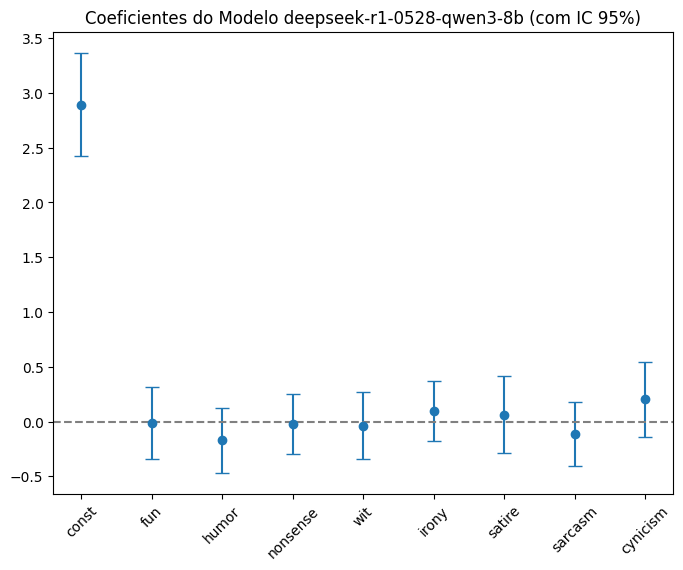

In [ ]:
models = list(explanations_merged_df['models_agreement_level_scores'][0].keys())
for model_name in models:
    X = explanations_merged_df[comic_columns]
    X = sm.add_constant(X)
    y = [scores[model_name] for scores in explanations_merged_df['models_agreement_level_scores']]

    model = sm.OLS(y, X).fit()
    print(f'--- {model_name} ---')
    print(model.summary())

    coefs = model.params
    conf = model.conf_int()
    errors = coefs - conf[0]

    plt.figure(figsize=(8, 6))
    plt.errorbar(coefs.index, coefs, yerr=errors, fmt='o', capsize=5)
    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(rotation=45)
    plt.title(f"Coeficientes do Modelo {model_name} (com IC 95%)")
    plt.show()